# Initial Downloading, Wrangling, Loading, and Saving Data

To perform the RFM calculation, the data will first be downloaded and cleaned before being loaded for calculations.
Exploratory Data Analysis (EDA) will be performed on both datasets, tough the full dataset will get only surface-level check.

---

Online Retail II UCI – Dataset Features:
- Invoice – Invoice number (6-digit integral number uniquely assigned to each transaction. If starting with 'C', it indicates a cancellation)
- StockCode – Product (item) code (5-digit integral number uniquely assigned to each distinct product)
- Description – Product (item) name
- Quantity – The quantities of each product (item) per transaction
- InvoiceDate – Invoice date and time (the day and time when a transaction was generated)
- Price – Unit price (product price per unit in sterling £)
- Customer ID – Customer number (a 5-digit integral number uniquely assigned to each customer)
- Country – Country name (the name of the country where a customer resides)

### Initial Imports

In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno 

# Local src
from src.clean_column_names import clean_column_names
from src.df_overview import df_overview
from src.generate_metadata import generate_metadata
from src.download_data import download_data

print('Done')

Done


## Data Acquisition

### Data Downloading and Loading

In [3]:
path_data = "mashlyn/online-retail-ii-uci"
download_data(path_data)

Data exists in D:\projects\customer-rfm-segmentation-dashboard\data\01_raw. Skipping.


In [4]:
path_csv = '../data/01_raw/online_retail_II.csv'
df = pd.read_csv(path_csv)
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


### Data Cleaning

In [5]:
df = clean_column_names(df)
df.columns

Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date',
       'price', 'customer_id', 'country'],
      dtype='object')

In [6]:
df_overview(df)

================================= Shape =================================
(1067371, 8)
================================= Info =================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   invoice       1067371 non-null  object 
 1   stock_code    1067371 non-null  object 
 2   description   1062989 non-null  object 
 3   quantity      1067371 non-null  int64  
 4   invoice_date  1067371 non-null  object 
 5   price         1067371 non-null  float64
 6   customer_id   824364 non-null   float64
 7   country       1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
================================= Columns =================================
Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date',
       'price', 'customer_id', 'country'],
      dtype='obj

- It shows that price and quantity takes minus values in the dataset; 
- the column customer_id is float;
- the column invoice_date is object;
- 243k missing customer IDs and 4k of descriptions;
- negative values in price & quantity columns;
- 1m+ total records;
- quantities take large numbers 81k;
- 34k of duplicates;

In [7]:
print(df['customer_id'].isnull().sum() / df.shape[0])
print(df['description'].isnull().sum() / df.shape[0])

0.22766872999172733
0.0041054141437232225


- 22.8% of customer IDs are NaNs;
- 0.4% of descriptions are NaNs;

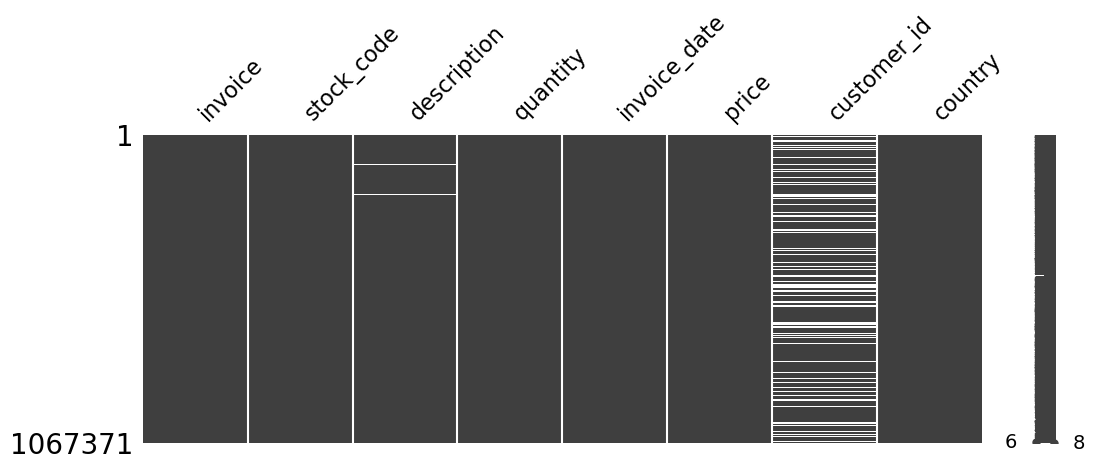

In [8]:
msno.matrix(df, figsize=(12, 4))
plt.show()

- the missing values in customer_id can be guests, as no easy pattern in missing values;

### Analysis of Negative and Zero Values in Quantities & Prices

Check the frequency of negative or zero values in the dataset to determine their impact and decide on an appropriate handling strategy (e.g., removal or imputation).

In [9]:
print(df.loc[df['quantity'] < 0].shape)
print(df.loc[df['quantity'] == 0].shape)
print(df.loc[df['price'] < 0].shape)
print(df.loc[df['price'] == 0].shape)

(22950, 8)
(0, 8)
(5, 8)
(6202, 8)


- 23k of entries where quantity is negative; either logging/other issues or refunds
- 6k of entries where price is negative; probably logging/other issues

In [10]:
df.loc[df['quantity'] < 0, :]

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


- invoice starts with C in quantity < 0, can be mark of cancellation and return;

In [11]:
df.loc[(df['invoice'].str.startswith('C', na=False)) & (df['quantity'] > 0)]

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom


- only one entry with C that has positive quantity;

In [12]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
965610,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.95,15110.0,United Kingdom
986868,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom
986869,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom
1055441,C580764,22667,RECIPE BOX RETROSPOT,-12,2011-12-06 10:38:00,2.95,14562.0,United Kingdom


- duplicates can be due to logging issues.

In [13]:
df = df[df['price'] != 0].copy()
df = df[df['price'] > 0].copy()
#df = df[df['quantity'] > 0].copy()
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['description'] = df['description'].str.strip()

In [14]:
print(f"Before: {len(df)}")
df = df.dropna(subset=['customer_id'])
df['customer_id'] = df['customer_id'].astype(int)
print(f"After dropping null customer_id: {len(df)}")

Before: 1061164
After dropping null customer_id: 824293


In [15]:
print(f"Before: {len(df)}")
df = df.drop(df.loc[(df['invoice'].str.startswith('C', na=False)) & (df['quantity'] > 0)].index).copy()
print(f"After dropping 'C' invoices with positive quantity: {len(df)}")

Before: 824293
After dropping 'C' invoices with positive quantity: 824293


In [16]:
print(f"Before: {len(df)}")
df = df.drop_duplicates().copy()
print(f"After dropping duplicates: {len(df)}")

Before: 824293
After dropping duplicates: 797815


- dropped empty customer_id columns, as they cannot be filled;
- converted customer_id column type to int for sql loading;
- converted invoice_date column type to datetime for plotting.
- dropped negative and zero values from price column;
- dropped duplicates, as they are probably system log issues;

In [17]:
tmp = df.sort_values(by='price', ascending=False)
print(tmp['description'].head(1000).unique().tolist())
print(tmp['stock_code'].head(1000).unique().tolist())

['Manual', 'POSTAGE', 'Discount', 'DOTCOM POSTAGE', 'CRUK Commission', 'PICNIC BASKET WICKER 60 PIECES', 'Adjustment by john on 26/01/2010 17', 'Adjustment by Peter on Jun 25 2010', 'Adjustment by Peter on 24/05/2010 1', 'Adjustment by john on 26/01/2010 16', 'VINTAGE RED KITCHEN CABINET', 'VINTAGE BLUE KITCHEN CABINET', 'LOVE SEAT ANTIQUE WHITE METAL', 'RUSTIC  SEVENTEEN DRAWER SIDEBOARD', 'REGENCY MIRROR WITH SHUTTERS', 'GIANT SEVENTEEN DRAWER SIDEBOARD', 'CARRIAGE', 'BLUE KASHMIRI COFFEE TABLE', 'ANT WHITE SWEETHEART TABLE W 3 DRAW', 'FRENCH STYLE WALL DRESSER', 'CHEST NATURAL WOOD 20 DRAWERS', 'VINTAGE POST OFFICE CABINET', 'BLUE KASHMIRI OCCASIONAL TABLE', 'GREEN KASHMIRI OCCASIONAL TABLE', 'PINK KASHMIRI OCCASIONAL TABLE', 'SCHOOL DESK AND CHAIR', 'PINK PAINTED KASHMIRI TABLE', 'BLUE PAINTED KASHMIRI TABLE', 'PINK KASHMIRI COFFEE TABLE', 'DECORATIVE HANGING SHELVING UNIT', 'SET/3 COLOUR PAINTED KASHMIRI STOOL', 'BROCADE RING PURSE']
['M', 'POST', 'D', 'DOT', 'CRUK', '22502', 'ADJ

In [18]:
df[df['stock_code'] == 'C2']

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
9292,490127,C2,CARRIAGE,1,2009-12-03 18:13:00,50.0,14156,EIRE
14502,490542,C2,CARRIAGE,1,2009-12-07 09:42:00,50.0,14911,EIRE
19541,490998,C2,CARRIAGE,1,2009-12-08 17:24:00,50.0,16253,United Kingdom
22803,491160,C2,CARRIAGE,1,2009-12-10 10:29:00,50.0,14911,EIRE
32964,492092,C2,CARRIAGE,1,2009-12-15 14:03:00,50.0,14156,EIRE
...,...,...,...,...,...,...,...,...
1038663,579539,C2,CARRIAGE,1,2011-11-30 10:06:00,50.0,14911,EIRE
1040462,579768,C2,CARRIAGE,1,2011-11-30 15:08:00,50.0,14911,EIRE
1041945,579910,C2,CARRIAGE,1,2011-12-01 08:52:00,50.0,14911,EIRE
1044366,580127,C2,CARRIAGE,1,2011-12-01 17:51:00,50.0,14911,EIRE


- many rows with large prices are invalid, the amounts are large (outliers) and as they are not products, it is not suitable for calculations; 

P.S. after a bit of research found that the UCI Online Retail II dataset has defined non-product stock codes..

In [19]:
non_product_keywords = [
    'manual', 
    'postage', 
    'dotcom postage', 
    'bank charges', 
    'amazon fee', 
    'discount', 
    'cruk commission', 
    'adjust',
    'carriage'
]
non_product_codes = ['POST', 'DOT', 'M', 'D', 'C2', 'S', 'AMAZONFEE', 
                     'BANK CHARGES', 'PADS', 'CRUK']

df = df[~df['stock_code'].isin(non_product_codes)]

additional_non_product_keywords = ['adjust']

pattern = '|'.join(non_product_keywords)
df = df[~df['description'].str.lower().str.contains(pattern, na=False)].copy()

- dropped non-product transactions;

In [20]:
tmp = df.sort_values(by='quantity', ascending=False)
print(tmp[['description', 'stock_code', 'price', 'quantity']].head(50))
print(tmp[['description', 'stock_code', 'price', 'quantity']].tail(50))

                                 description stock_code  price  quantity
1065882          PAPER CRAFT , LITTLE BIRDIE      23843   2.08     80995
587080        MEDIUM CERAMIC TOP STORAGE JAR      23166   1.04     74215
90857     BLACK AND WHITE PAISLEY FLOWER MUG      37410   0.10     19152
127166           SET/6 STRAWBERRY PAPER CUPS      21099   0.10     12960
127168           SET/6 WOODLAND PAPER PLATES      21091   0.10     12960
127169             SET/6 WOODLAND PAPER CUPS      21085   0.10     12744
127167         SET/6 STRAWBERRY PAPER PLATES      21092   0.10     12480
135027       PACK OF 12 PINK PAISLEY TISSUES      21984   0.25     10000
135029         PACK OF 12 RED SPOTTY TISSUES      21980   0.25     10000
135028               PACK OF 12 SUKI TISSUES      21982   0.25     10000
135030           PACK OF 12 WOODLAND TISSUES      21981   0.25     10000
93677        SMALL FAIRY CAKE FRIDGE MAGNETS      85220   0.30      9456
432176   ROTATING SILVER ANGELS T-LIGHT HLDR      8

- big positive & negative quantities are valid, as they capture regular purchases & returns;

In [21]:
df['revenue'] = df['quantity'] * df['price']
df.groupby('customer_id')['revenue'].sum().describe()

count      5875.000000
mean       2784.038625
std       13798.792564
min       -1343.240000
25%         328.000000
50%         835.220000
75%        2164.280000
max      578408.640000
Name: revenue, dtype: float64

- some of our customers are having negative revenue, probably data on their initial purchase was not collected, but return was; 
- the negative qty will be dropped for RFM calc, but will be left in the base dataset to preserve a possibility to make a deep analysis of huge cancellations;

In [22]:
tmp = df.groupby('customer_id')['revenue'].sum().reset_index()
negative_ids = tmp['customer_id'][tmp['revenue'] < 0]
df = df[~df['customer_id'].isin(negative_ids)].copy()
df

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


- dropped all transactions of customers that would have negative revenue balance in the monetary from the main df;

In [23]:
print(df[['country', 'revenue', 'invoice_date']].sort_values(by='invoice_date', ascending=False).head(50))
print(df[['country', 'revenue', 'invoice_date']].sort_values(by='invoice_date', ascending=False).tail(50))

                country  revenue        invoice_date
1067369          France    14.85 2011-12-09 12:50:00
1067362          France    15.60 2011-12-09 12:50:00
1067356          France    19.80 2011-12-09 12:50:00
1067357          France    19.80 2011-12-09 12:50:00
1067358          France    15.00 2011-12-09 12:50:00
1067359          France    15.00 2011-12-09 12:50:00
1067360          France    15.00 2011-12-09 12:50:00
1067361          France    15.00 2011-12-09 12:50:00
1067355          France    23.40 2011-12-09 12:50:00
1067363          France    23.40 2011-12-09 12:50:00
1067365          France    10.20 2011-12-09 12:50:00
1067366          France    12.60 2011-12-09 12:50:00
1067367          France    16.60 2011-12-09 12:50:00
1067368          France    16.60 2011-12-09 12:50:00
1067364          France    16.60 2011-12-09 12:50:00
1067353  United Kingdom   214.80 2011-12-09 12:49:00
1067352  United Kingdom    30.00 2011-12-09 12:49:00
1067351  United Kingdom    23.60 2011-12-09 12

- the records start and end smoothly, in Dec, right before New Year;

In [24]:
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month
print(df.columns)

Index(['invoice', 'stock_code', 'description', 'quantity', 'invoice_date',
       'price', 'customer_id', 'country', 'revenue', 'year', 'month'],
      dtype='object')


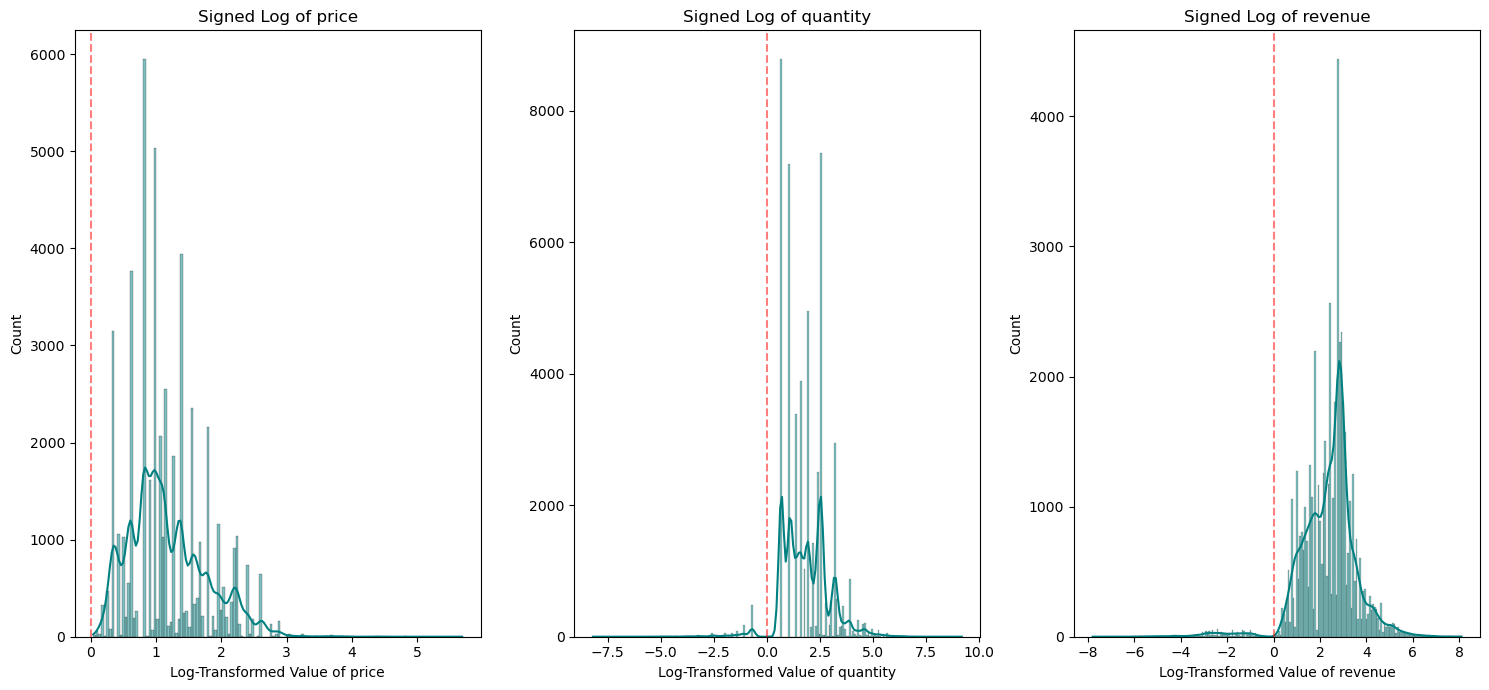

In [25]:
dist_cols = ['price', 'quantity', 'revenue']
df_sample = df[dist_cols].sample(n=50000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 7))

for i, col in enumerate(dist_cols):
    log_data = np.sign(df_sample[col]) * np.log1p(df_sample[col].abs()) 
    
    sns.histplot(log_data, kde=True, ax=axes[i], color='teal')
    
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
    
    axes[i].set_title(f"Signed Log of {col}")
    axes[i].set_xlabel(f"Log-Transformed Value of {col}")

plt.tight_layout()
plt.show()

- see before detected outliers in quantity and therefore in revenue generated feature;

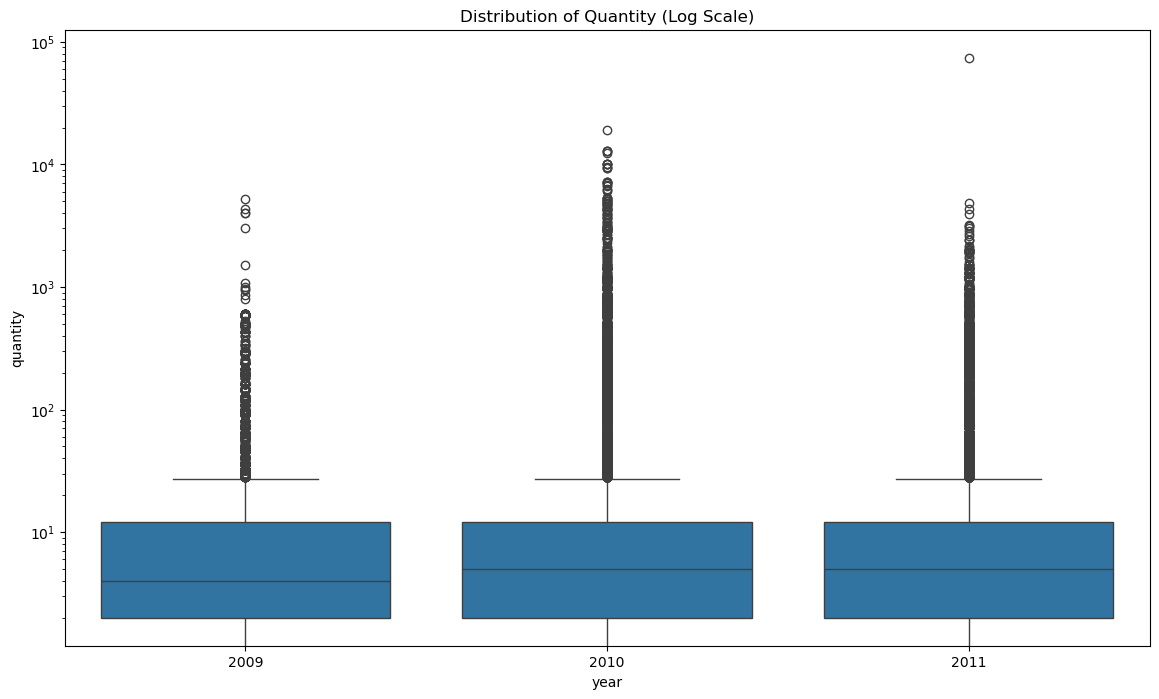

In [26]:
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='year', y='quantity', data=df)

ax.set_yscale("log") 

plt.title('Distribution of Quantity (Log Scale)')
plt.show()

- see the consistency in order sizes across years (50% of all is 2-12 units per order);
- 2010 has spike of high volume order compared to 2009 (1 month) and 2011;

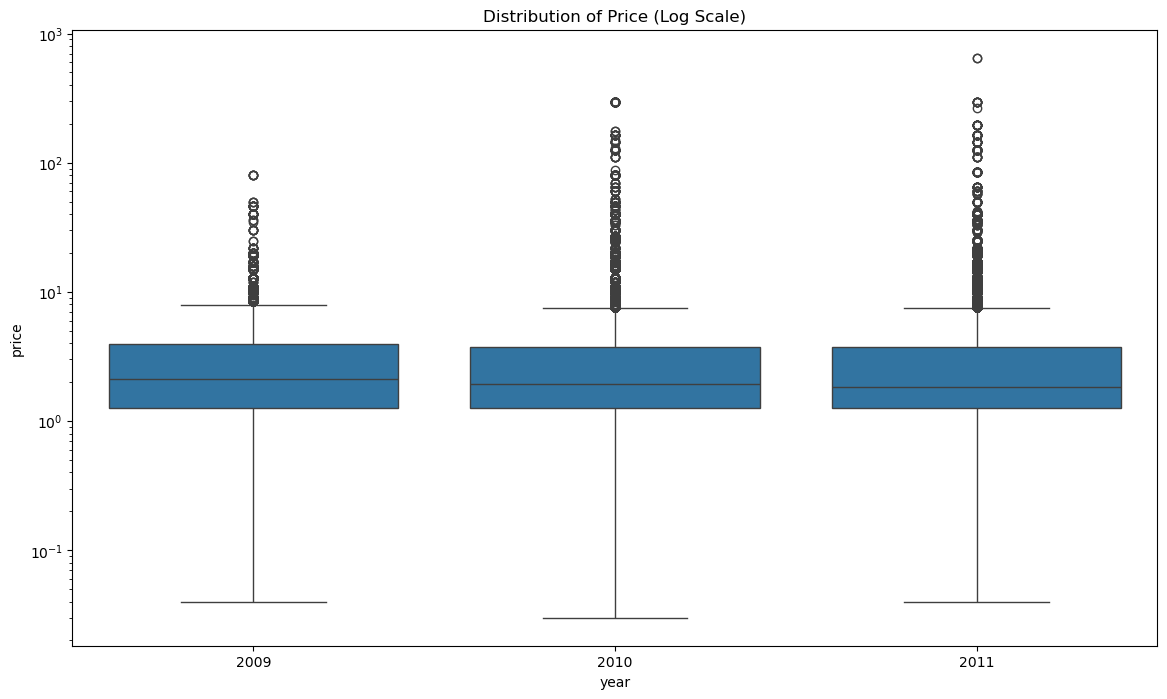

In [27]:
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='year', y='price', data=df)

ax.set_yscale("log") 

plt.title('Distribution of Price (Log Scale)')
plt.show()

- see a lot of outliers, but can be used NTILE (SQL) and qcut (pandas) to handle them when calculating rfm; (monetary will be huge and without handling it only the big players will be marked as valuable);

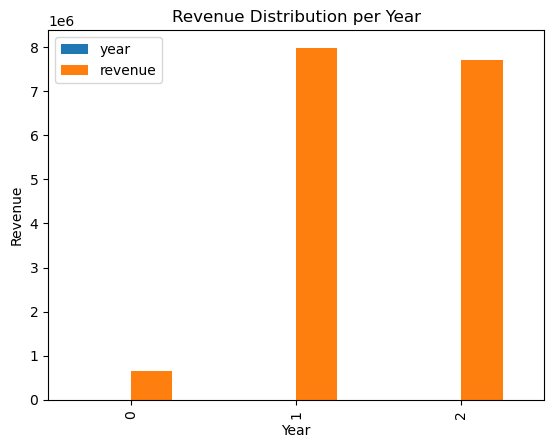

In [28]:
year_rev = df.groupby('year')['revenue'].sum().reset_index()
year_rev.plot(kind='bar')
plt.title('Revenue Distribution per Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()

- the total revenue are roughly the same for 2010 (1) and 2011 (2);

Text(0.5, 1.0, 'Monthly Revenue Trend')

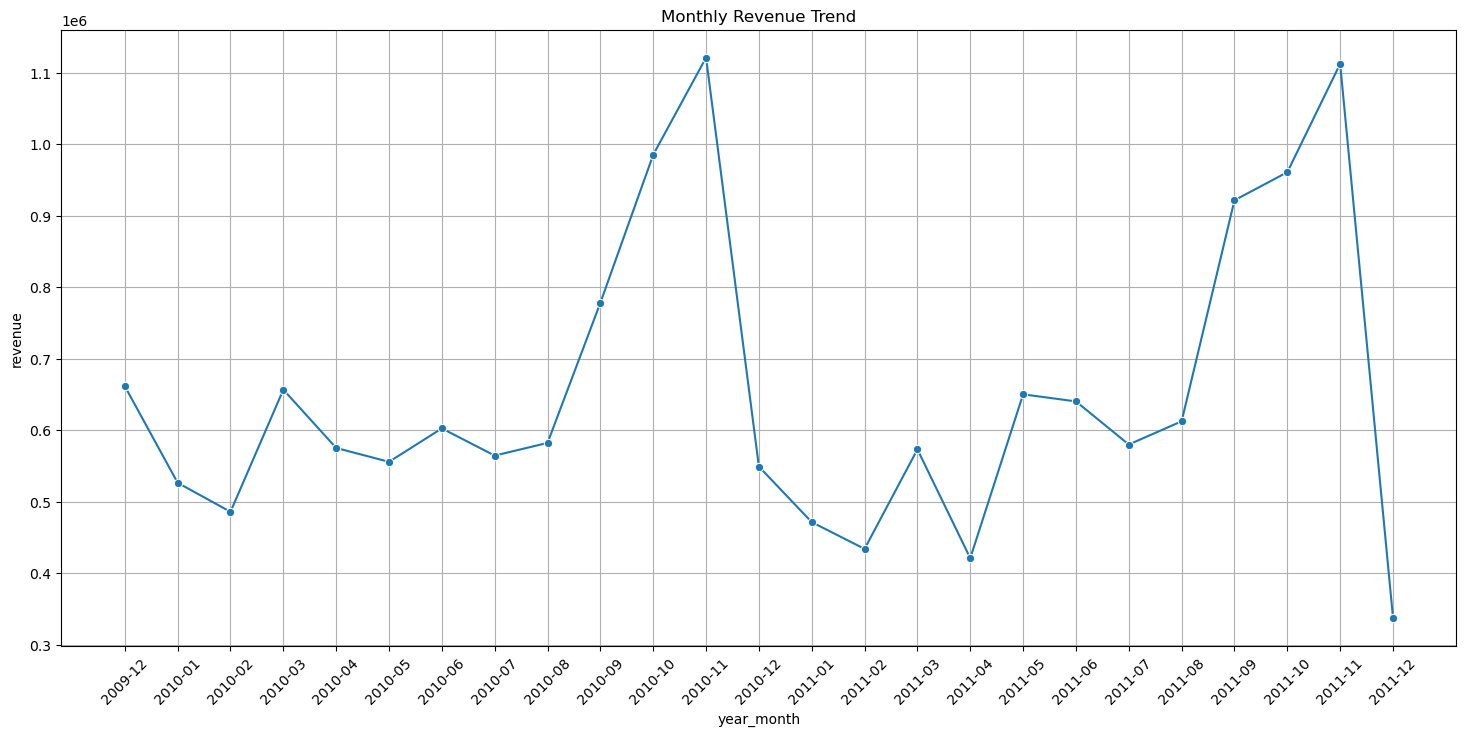

In [29]:
year_month_rev = df.groupby(['year','month'])['revenue'].sum().reset_index()
year_month_rev['year_month'] = year_month_rev['year'].astype(str) + '-' + year_month_rev['month'].astype(str).str.zfill(2)
year_month_rev = year_month_rev.sort_values('year_month')

plt.figure(figsize=(18, 8))
sns.lineplot(data=year_month_rev, x='year_month', y='revenue', marker='o')
plt.xticks(rotation=45)
plt.grid()
plt.title('Monthly Revenue Trend')

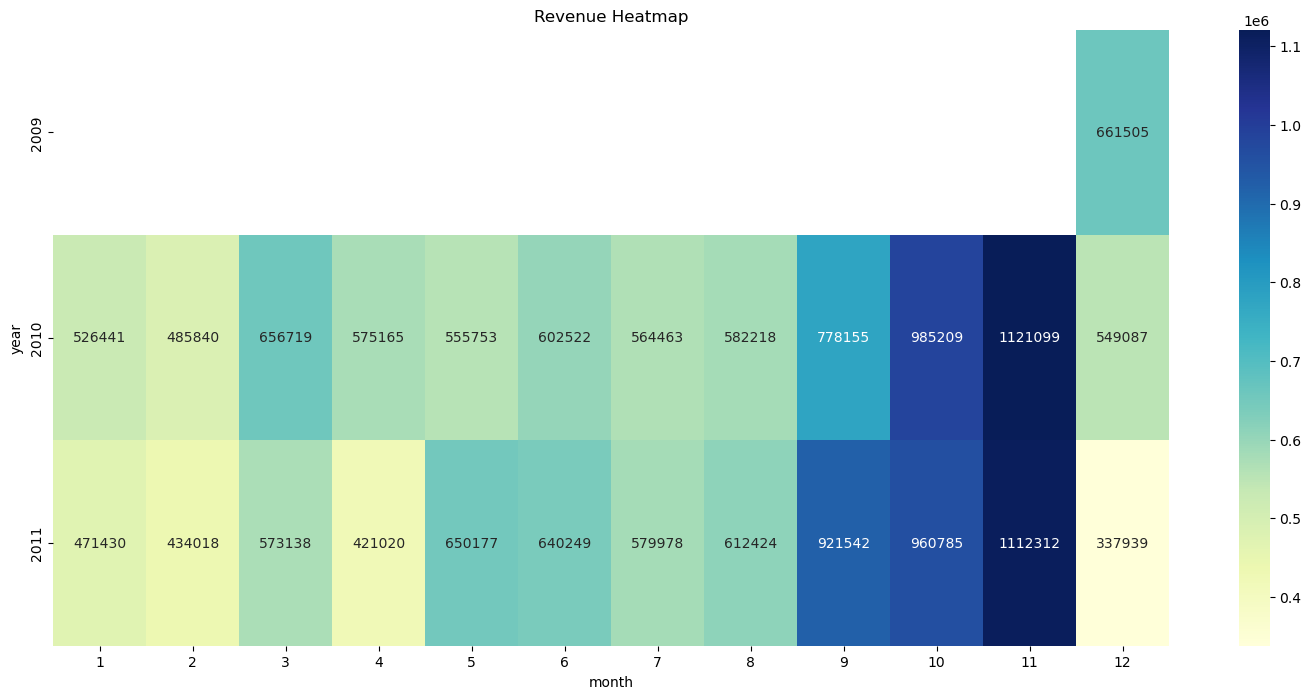

In [30]:
pivot_rev = year_month_rev.pivot(index='year', columns='month', values='revenue')

plt.figure(figsize=(18, 8))
sns.heatmap(pivot_rev, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Revenue Heatmap')
plt.show()

- see 2 spikes of monthly revenue in Oct-Nov in years 2010 and 2011; can be due to purchases before New Year; (pre-holiday surge)
- see 2 huge drop (to norm) of monthly revenue in Dec in years 2010 and 2011; probably due to the peak; (post-peak exhaustion)

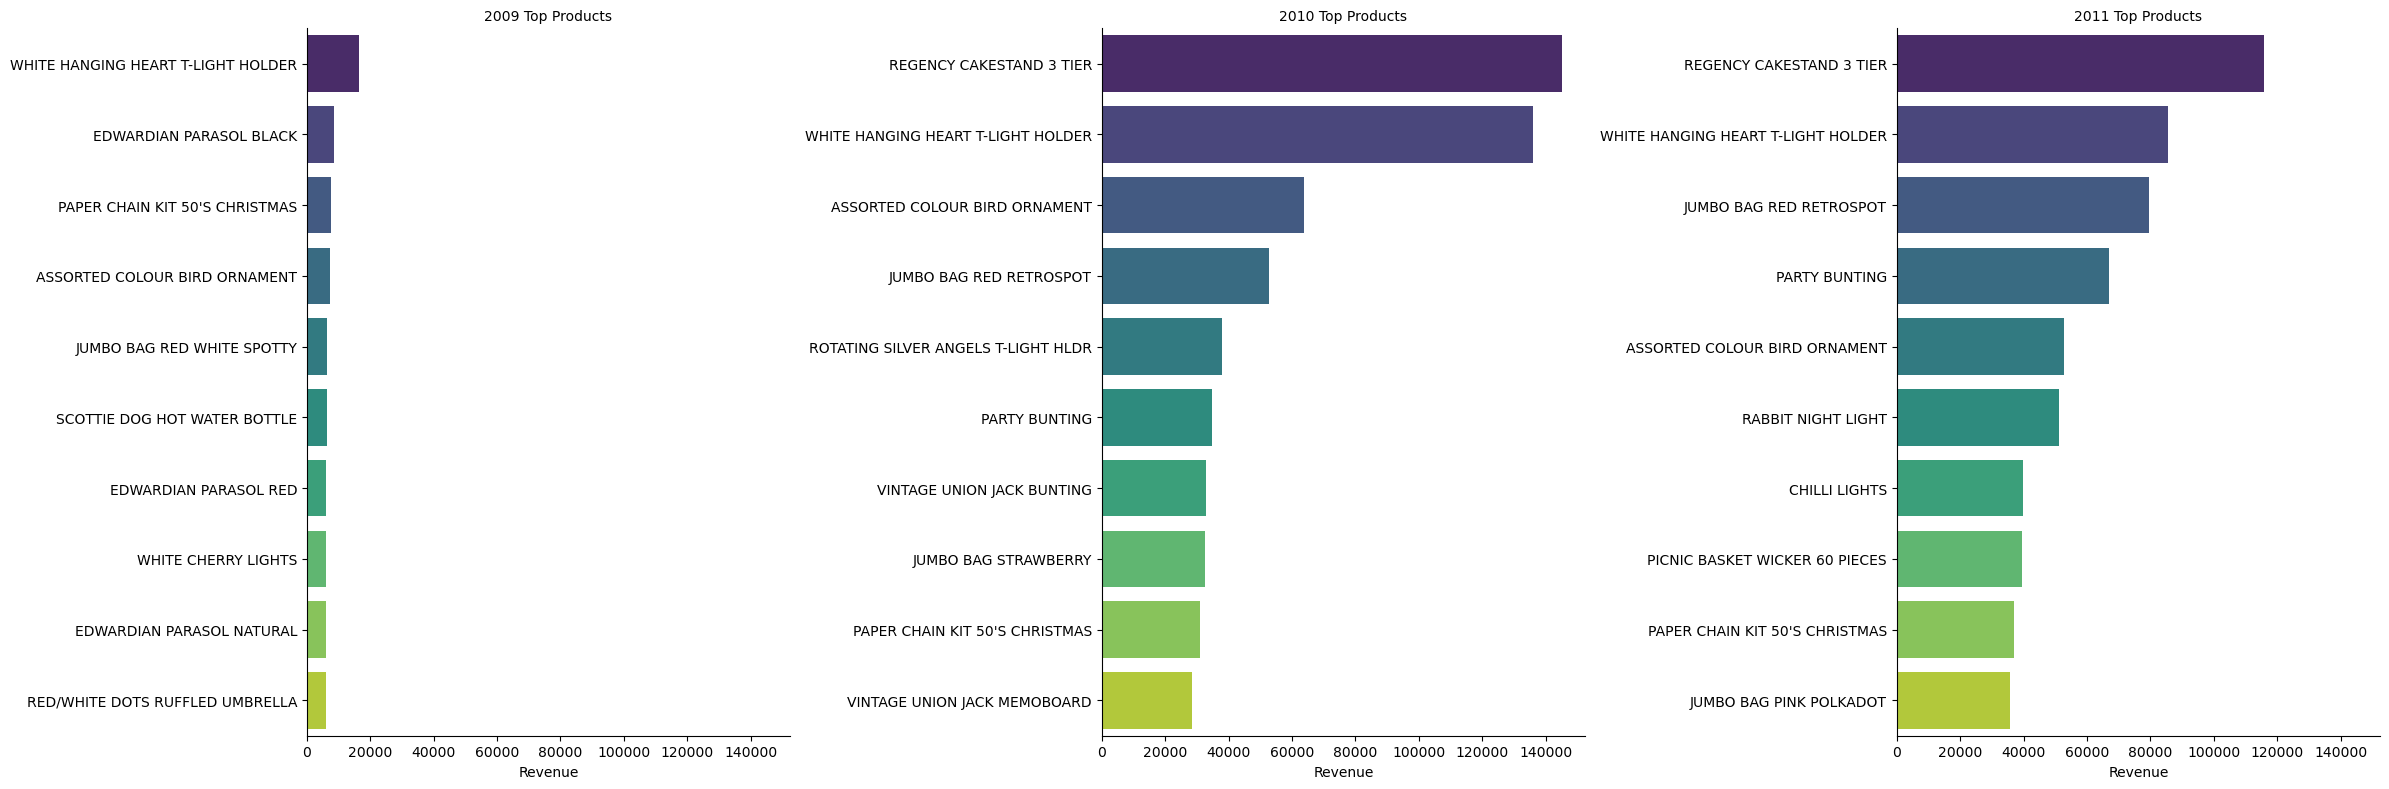

In [31]:
year_product_rev = df.groupby(['year', 'stock_code', 'description'])['revenue'].sum().reset_index()
year_product_rev = year_product_rev.sort_values(['year', 'revenue'], ascending=[True, False])

top_10_per_year = year_product_rev.groupby('year').head(10).reset_index()
top_10_per_year = top_10_per_year.drop(columns='index').copy()

g = sns.FacetGrid(top_10_per_year, col="year", col_wrap=3, height=8, aspect=1, sharey=False)

g.map_dataframe(
    sns.barplot, 
    x="revenue", 
    y="description", 
    hue="description",  #
    palette="viridis", 
    legend=False       
)

g.set_titles("{col_name} Top Products")
g.set_axis_labels("Revenue", "")

plt.tight_layout()
plt.show()

-  top 10 bestsellers per year, can be used in product analysis;

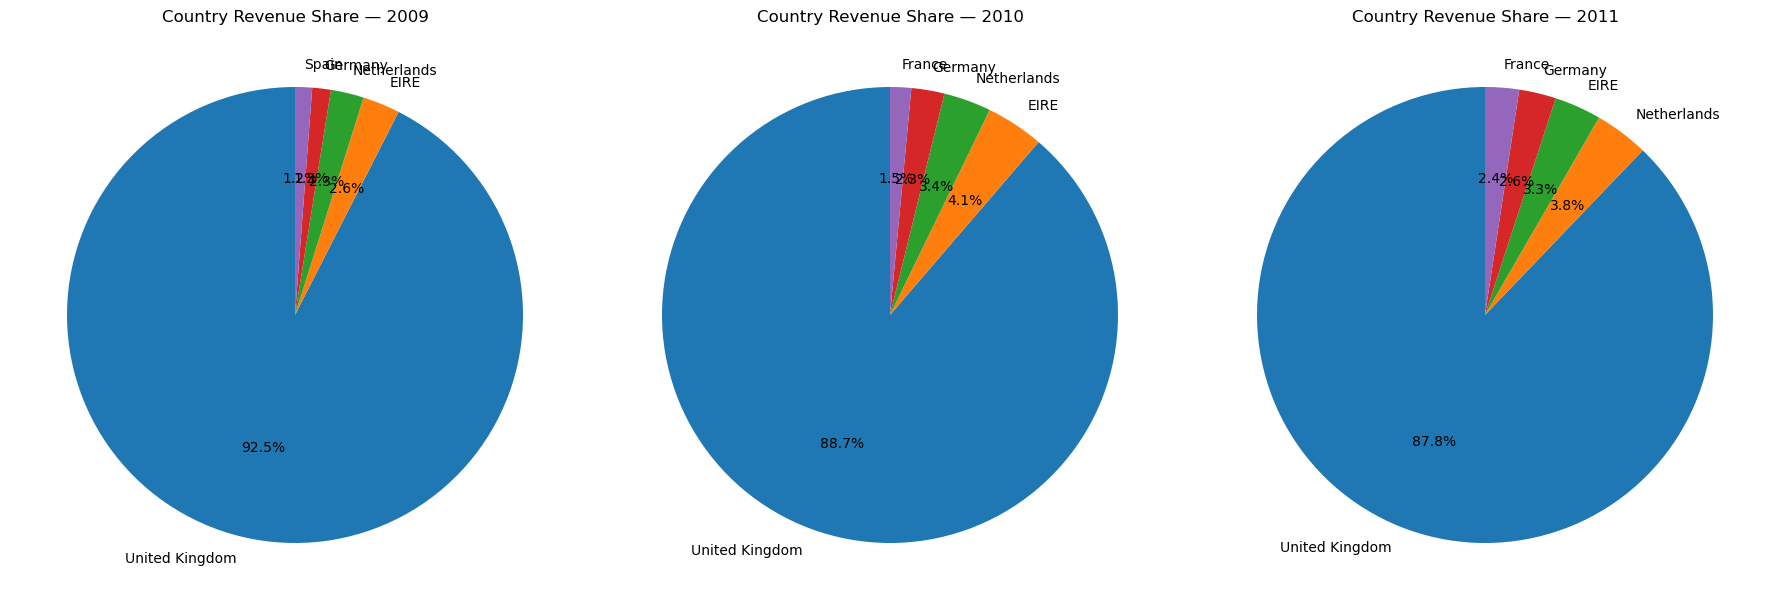

In [32]:
year_country_rev = (
    df.groupby(['year', 'country'])['revenue']
      .sum()
      .reset_index()
)

top_5_per_year = (
    year_country_rev
    .sort_values(['year', 'revenue'], ascending=[True, False])
    .groupby('year')
    .head(5)
)

years = sorted(top_5_per_year['year'].unique())

fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 6))

if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    data_year = top_5_per_year[top_5_per_year['year'] == year]

    ax.pie(
        data_year['revenue'],
        labels=data_year['country'],
        autopct='%1.1f%%',
        startangle=90
    )
    ax.set_title(f'Country Revenue Share — {year}')

plt.tight_layout()
plt.show()


- the money flow mostly comes from UK (approx. 88.5%); should consider segmentation separated for UK and Others;

In [33]:
df.groupby('customer_id')['country'].value_counts().sort_values(ascending=False).head(20)

customer_id  country       
17841        United Kingdom    12623
14911        EIRE              11248
12748        United Kingdom     6624
14606        United Kingdom     6486
14096        United Kingdom     5093
15311        United Kingdom     4568
14156        EIRE               4066
14646        Netherlands        3848
13089        United Kingdom     3390
16549        United Kingdom     3098
14298        United Kingdom     2867
15039        United Kingdom     2713
14527        United Kingdom     2703
17850        United Kingdom     2526
15005        United Kingdom     2478
13081        United Kingdom     2351
17511        United Kingdom     2075
13263        United Kingdom     1900
14159        United Kingdom     1844
15719        United Kingdom     1781
Name: count, dtype: int64

- most customers with the biggest transaction volume are from UK;

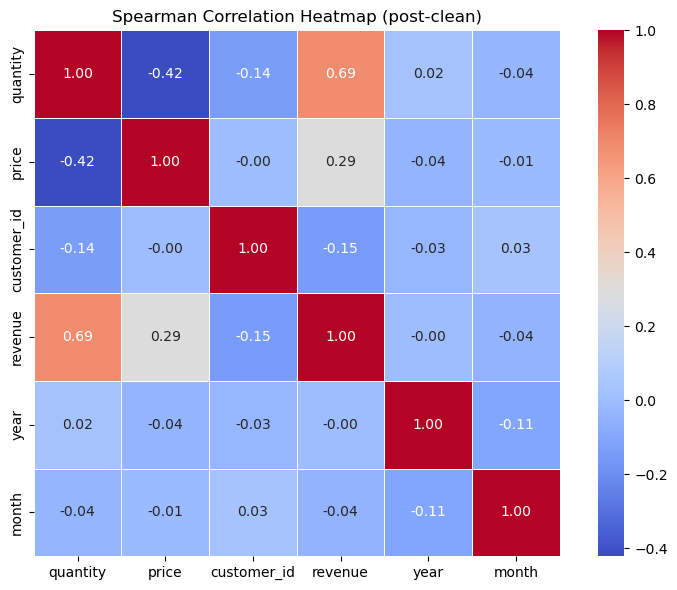

In [34]:
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Spearman Correlation Heatmap (post-clean)')
plt.tight_layout()
plt.show()

- more money comes from qty (.69), rather than from price (.29), plus they have negative corr that proves the point (-.42)

Days with zero transactions: 135
2009-12-12    0
2009-12-19    0
2009-12-24    0
2009-12-25    0
2009-12-26    0
2009-12-27    0
2009-12-28    0
2009-12-29    0
2009-12-30    0
2009-12-31    0
2010-01-01    0
2010-01-02    0
2010-01-03    0
2010-01-09    0
2010-01-16    0
2010-01-23    0
2010-01-30    0
2010-02-06    0
2010-02-13    0
2010-02-20    0
dtype: int64


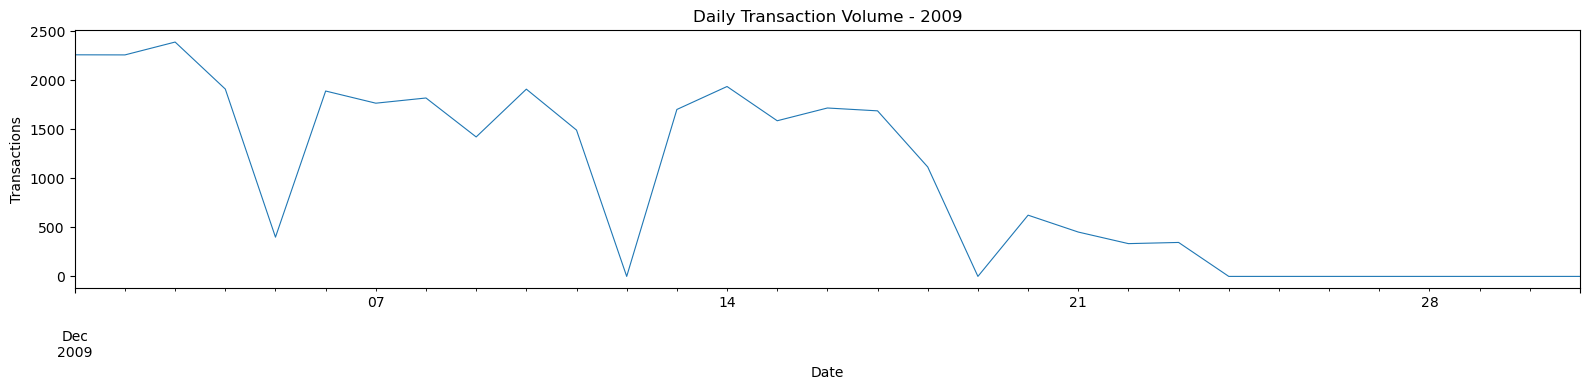

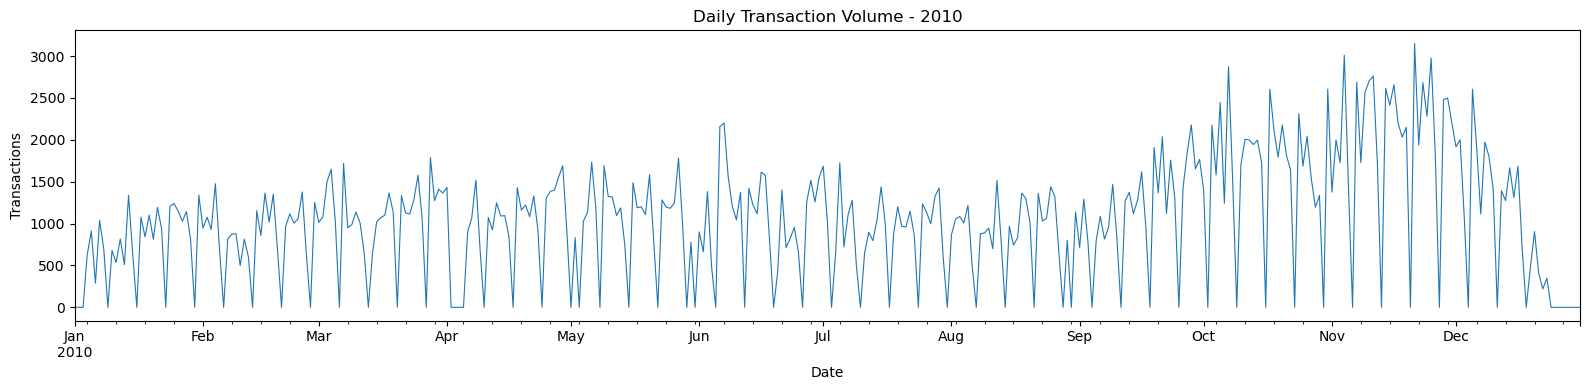

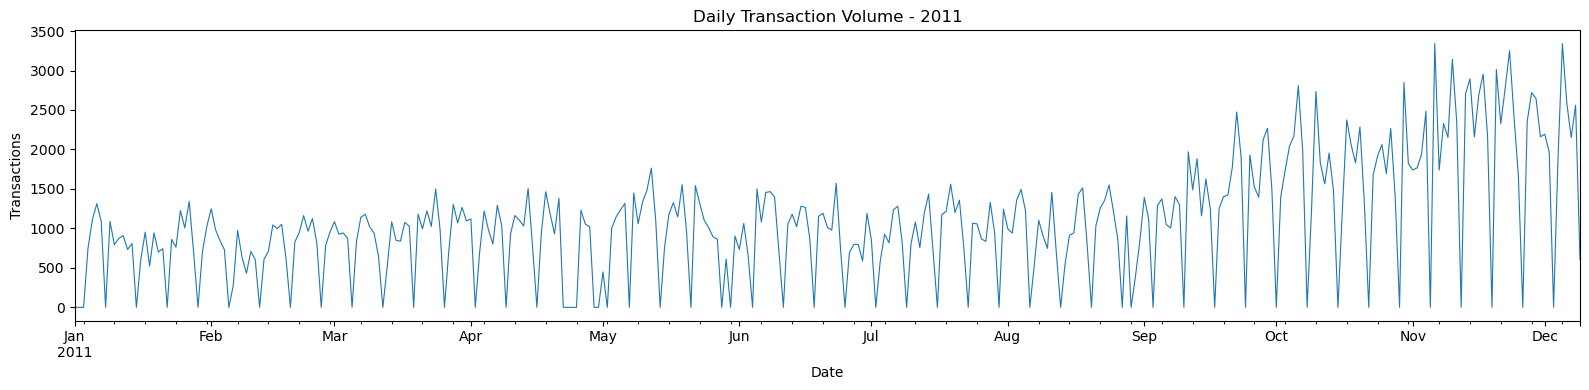

In [ ]:
daily_counts = df.set_index('invoice_date').resample('D').size()
daily_counts = daily_counts.reindex(
    pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq='D'),
    fill_value=0
)

zero_days = daily_counts[daily_counts == 0]
print(f"Days with zero transactions: {len(zero_days)}")
print(zero_days.head(20))

years = daily_counts.index.year.unique()

for year in years:
    daily_counts_year = daily_counts[daily_counts.index.year == year]
    fig, ax = plt.subplots(figsize=(16, 4))
    daily_counts_year.plot(ax=ax, linewidth=0.8)
    ax.set_title(f'Daily Transaction Volume - {year}')
    ax.set_ylabel('Transactions')
    ax.set_xlabel('Date')
    plt.tight_layout()
    plt.show()

- no huge gaps detected beside jan (holidays);
- some drops in transaction volume detected, but no value for the analysis;

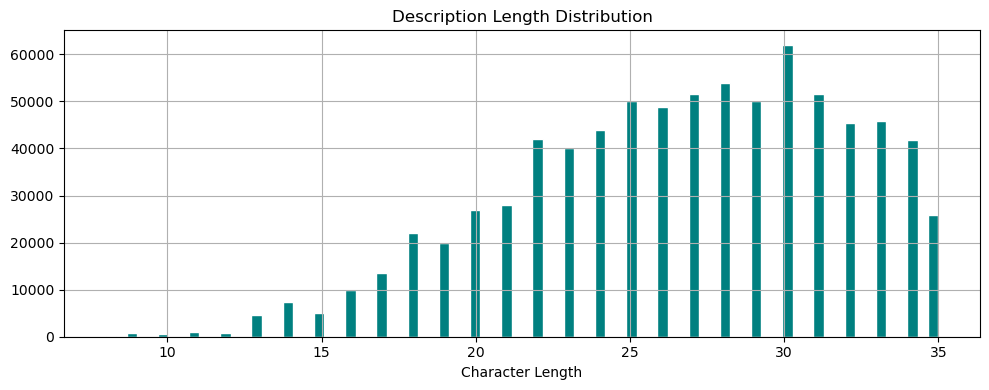

Shortest descriptions:
Series([], Name: count, dtype: int64)

Descriptions containing '?':
Series([], Name: count, dtype: int64)


In [37]:
desc = df['description'].dropna()
desc_len = desc.str.len()

fig, ax = plt.subplots(figsize=(10, 4))
desc_len.hist(bins=80, ax=ax, color='teal', edgecolor='white')
ax.set_title('Description Length Distribution')
ax.set_xlabel('Character Length')
plt.tight_layout()
plt.show()

print("Shortest descriptions:")
print(desc.loc[desc_len < 5].value_counts().head(20))
print("\nDescriptions containing '?':")
print(desc[desc.str.contains(r'\?', na=False)].value_counts().head(10))

- no anomalies in the descriptions;

In [ ]:
pd_to_csv_path = os.path.join('..', 'data', '02_processed', 'base_retail.csv')

os.makedirs(os.path.dirname(pd_to_csv_path), exist_ok=True)
df.to_csv(pd_to_csv_path, index=False)

print(f"Saved to: {pd_to_csv_path}")

Metadata saved: ..\data\02_processed\base_retail_metadata.json
Saved to: ..\data\02_processed\base_retail.csv


- saved processed base dataset for further feature engineering and eda;
- metadata is generated as it helps both humans and AI tools (in my case Copilot) understand schema;

## Summary of Initial EDA and Data Cleaning

### Key Data Quality Issues Identified:
- **22.8%** of customer IDs were missing (likely guest transactions)
- **0.4%** of product descriptions were missing  
- **34,000** duplicate records identified
- **23,000** entries with negative quantities (returns/cancellations)
- **6,000** entries with negative prices (data quality issues)
- Non-product transactions included (postage, fees, adjustments)

### Data Cleaning Steps Applied:
1. **Removed invalid transactions**: Zero/negative prices, non-product codes (POST, DOT, M, D, C2, etc.)
2. **Handled missing values**: Dropped records with missing customer IDs (cannot perform customer-level RFM without ID)
3. **Return/cancellation logic**: Invoice codes starting with 'C' indicate cancellations
4. **Revenue consistency**: Removed customers with negative total revenue balance
5. **Deduplication**: Removed 34k duplicate records
6. **Feature engineering**: Created `revenue` column (quantity × price), extracted `year` and `month`

### Key Insights:
- **Geographic concentration**: UK dominates with **~88.5%** of total revenue
- **Seasonality patterns**: Revenue spikes in **October-November** (pre-holiday surge), drops in December
- **Revenue drivers**: Quantity drives revenue more than price (correlation: 0.69 vs 0.29)
- **Price-quantity relationship**: **Negative correlation (-0.42)** suggests volume discounting
- **Dataset timespan**: December 2009 - December 2011 (2 full years)
- **Order behavior**: Median order size consistently 2-12 units across years

### Next Steps:
The cleaned dataset has been saved to `../data/02_processed/base_retail.csv` and is ready for:
1. RFM metric calculations & other feature engineering
2. Customer segmentation modeling

*Note: The dataset maintains both positive and negative quantities to preserve return/cancellation patterns for comprehensive customer behavior analysis.*